<a href="https://colab.research.google.com/github/snehabvarghese/NER_transformers/blob/main/NER_Transformers_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔎 Advanced Named Entity Recognition (NER) using Hugging Face Transformers

**Extract Person, Organization, Location, Date, Money, and Time entities from any English text.**

This notebook:
- Loads a state-of-the-art pretrained Transformer NER model (`Jean-Baptiste/roberta-large-ner-english` or `dslim/bert-base-NER`)
- Auto-detects and uses GPU when available
- Accepts raw text, `.txt`, or `.pdf` input
- Merges sub-word tokens, removes duplicates, and scores confidence
- Adds rule-based extraction for **Date**, **Money**, and **Time** (categories not covered by standard CoNLL-trained NER models) so all 6 requested entity types are covered
- Visualizes results (highlighted text, bar chart, pie chart)
- Exports results to CSV
- Ships a Gradio web app, runnable directly inside Colab

> **Note on entity coverage:** Off-the-shelf Transformer NER models (RoBERTa-NER, BERT-NER) are trained on the CoNLL-2003 scheme, which natively predicts `PER`, `ORG`, `LOC`, and `MISC` — **not** `DATE`, `MONEY`, or `TIME`. To satisfy the full 6-category requirement, this notebook combines the Transformer model (for Person/Organization/Location) with high-precision regex/rule-based extractors (for Date/Money/Time). This is the standard production pattern used when a single model doesn't cover every desired label.


## 1️⃣ Install Dependencies

In [ ]:
# Install all required libraries (quiet mode). Safe to re-run.
!pip install -q transformers accelerate torch sentencepiece
!pip install -q gradio
!pip install -q pypdf
!pip install -q pandas matplotlib
print("✅ All dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 27.3 MB/s eta 0:00:00
✅ All dependencies installed.


## 2️⃣ Imports & Configuration

In [ ]:
import re
import io
import os
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", None)

# ---- Configuration ----
MODEL_OPTIONS = {
    "roberta-large-ner-english": "Jean-Baptiste/roberta-large-ner-english",
    "bert-base-NER": "dslim/bert-base-NER",
}

# Choose the active model here. Both are CoNLL-style (PER/ORG/LOC/MISC).
ACTIVE_MODEL_KEY = "roberta-large-ner-english"
ACTIVE_MODEL_NAME = MODEL_OPTIONS[ACTIVE_MODEL_KEY]

print(f"Selected model: {ACTIVE_MODEL_NAME}")


Selected model: Jean-Baptiste/roberta-large-ner-english


## 3️⃣ GPU Detection & Model Loading

In [ ]:
def get_device() -> int:
    """Return the device index for the HF pipeline (-1 for CPU, 0 for first GPU)."""
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print(f"✅ GPU detected: {gpu_name}. Using CUDA for inference.")
        return 0
    print("⚠️ No GPU detected. Falling back to CPU (inference will be slower).")
    return -1


def load_ner_pipeline(model_name: str = ACTIVE_MODEL_NAME):
    """Load tokenizer + model and wrap them in a HF NER pipeline with sub-word aggregation."""
    device = get_device()
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForTokenClassification.from_pretrained(model_name)
        ner_pipe = pipeline(
            task="ner",
            model=model,
            tokenizer=tokenizer,
            aggregation_strategy="simple",  # merges sub-word tokens into full words automatically
            device=device,
        )
        print(f"✅ Loaded model '{model_name}' successfully.")
        return ner_pipe
    except Exception as e:
        raise RuntimeError(f"❌ Failed to load model '{model_name}': {e}")


ner_pipeline = load_ner_pipeline()


✅ GPU detected: Tesla T4. Using CUDA for inference.


config.json:   0%|          | 0.00/849 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ Loaded model 'Jean-Baptiste/roberta-large-ner-english' successfully.


## 4️⃣ Document Readers (.txt / .pdf)

In [ ]:
def read_txt_file(file_path: str) -> str:
    """Read plain text from a .txt file with graceful encoding fallback."""
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            return f.read()
    except UnicodeDecodeError:
        with open(file_path, "r", encoding="latin-1") as f:
            return f.read()
    except Exception as e:
        raise IOError(f"Could not read TXT file '{file_path}': {e}")


def read_pdf_file(file_path: str) -> str:
    """Extract text from a PDF file using pypdf."""
    try:
        from pypdf import PdfReader
        reader = PdfReader(file_path)
        text_parts = [page.extract_text() or "" for page in reader.pages]
        text = "\n".join(text_parts).strip()
        if not text:
            raise ValueError("No extractable text found (the PDF may be scanned/image-based).")
        return text
    except Exception as e:
        raise IOError(f"Could not read PDF file '{file_path}': {e}")


def load_document_text(file_path: Optional[str]) -> str:
    """Dispatch to the correct reader based on file extension."""
    if file_path is None:
        return ""
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".txt":
        return read_txt_file(file_path)
    elif ext == ".pdf":
        return read_pdf_file(file_path)
    else:
        raise ValueError(f"Unsupported file type '{ext}'. Please upload a .txt or .pdf file.")


## 5️⃣ Rule-Based Extractors for Date, Money & Time

The pretrained Transformer model does not emit `DATE`, `MONEY`, or `TIME` labels, so these are
extracted with carefully tuned regular expressions — a standard, fast, high-precision approach
for structured entity types.


In [ ]:
DATE_PATTERNS = [
    r"\b\d{1,2}(st|nd|rd|th)?\s+(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{2,4}\b",
    r"\b(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2}(st|nd|rd|th)?,?\s+\d{2,4}\b",
    r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
    r"\b\d{4}[/-]\d{1,2}[/-]\d{1,2}\b",
    r"\b(Mon|Tues?|Wed(nes)?|Thur?s?|Fri|Sat(ur)?|Sun)day\b",
]

TIME_PATTERNS = [
    r"\b\d{1,2}:\d{2}(:\d{2})?\s?(AM|PM|am|pm)?\b",
    r"\b\d{1,2}\s?(AM|PM|am|pm)\b",
    r"\b(noon|midnight)\b",
]

MONEY_PATTERNS = [
    r"[$€£¥₹]\s?\d[\d,]*(\.\d+)?\s?(million|billion|trillion|thousand|k|M|B)?",
    r"\b\d[\d,]*(\.\d+)?\s?(dollars|USD|euros|EUR|pounds|GBP|rupees|INR|yen|JPY)\b",
    r"\b\d[\d,]*(\.\d+)?\s?(million|billion|trillion)\s?(dollars|USD|euros|pounds|rupees)?\b",
]


def _extract_by_patterns(text: str, patterns: List[str], label: str) -> List[Dict[str, Any]]:
    """Run a list of regex patterns over text and return entity dicts in a NER-compatible shape."""
    results = []
    seen_spans = set()
    for pattern in patterns:
        for m in re.finditer(pattern, text, flags=re.IGNORECASE):
            span = (m.start(), m.end())
            if span in seen_spans:
                continue
            word = m.group(0).strip()
            if not word:
                continue
            seen_spans.add(span)
            results.append({
                "entity_group": label,
                "word": word,
                "score": 0.90,  # fixed high-confidence score for deterministic rule-based matches
                "start": m.start(),
                "end": m.end(),
            })
    return results


def extract_dates(text: str) -> List[Dict[str, Any]]:
    return _extract_by_patterns(text, DATE_PATTERNS, "DATE")


def extract_times(text: str) -> List[Dict[str, Any]]:
    return _extract_by_patterns(text, TIME_PATTERNS, "TIME")


def extract_money(text: str) -> List[Dict[str, Any]]:
    return _extract_by_patterns(text, MONEY_PATTERNS, "MONEY")


## 6️⃣ Core NER Extraction, Merging & Deduplication

In [ ]:
LABEL_MAP = {
    "PER": "Person",
    "PERSON": "Person",
    "ORG": "Organization",
    "LOC": "Location",
    "MISC": "Miscellaneous",
    "DATE": "Date",
    "MONEY": "Money",
    "TIME": "Time",
}

TARGET_LABELS = {"Person", "Organization", "Location", "Date", "Money", "Time"}


def run_transformer_ner(text: str) -> List[Dict[str, Any]]:
    """Run the Transformer NER pipeline and normalize its output."""
    if not text or not text.strip():
        return []
    try:
        raw_entities = ner_pipeline(text)
    except Exception as e:
        raise RuntimeError(f"NER inference failed: {e}")

    normalized = []
    for ent in raw_entities:
        raw_label = ent.get("entity_group", ent.get("entity", "MISC")).upper()
        mapped_label = LABEL_MAP.get(raw_label, "Miscellaneous")
        normalized.append({
            "entity_group": mapped_label,
            "word": ent["word"].strip(),
            "score": float(ent["score"]),
            "start": ent.get("start"),
            "end": ent.get("end"),
        })
    return normalized


def merge_and_deduplicate(entities: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """Remove duplicate entities (same normalized text + type), keeping the highest confidence."""
    best: Dict[tuple, Dict[str, Any]] = {}
    for ent in entities:
        key = (ent["word"].lower().strip(), ent["entity_group"])
        if key not in best or ent["score"] > best[key]["score"]:
            best[key] = ent
    # Sort by position in text for a readable, ordered output
    return sorted(best.values(), key=lambda e: (e.get("start") if e.get("start") is not None else 0))


def extract_all_entities(text: str) -> List[Dict[str, Any]]:
    """Full pipeline: Transformer NER (Person/Org/Location) + regex NER (Date/Money/Time)."""
    if not text or not text.strip():
        raise ValueError("Input text is empty. Please provide text or upload a document.")

    transformer_entities = run_transformer_ner(text)
    # Only keep transformer entities in our target label set (drop Miscellaneous, if desired keep it too)
    transformer_entities = [e for e in transformer_entities if e["entity_group"] in TARGET_LABELS]

    rule_entities = extract_dates(text) + extract_times(text) + extract_money(text)

    all_entities = transformer_entities + rule_entities
    return merge_and_deduplicate(all_entities)


def entities_to_dataframe(entities: List[Dict[str, Any]]) -> pd.DataFrame:
    """Convert extracted entities into a clean, professional Pandas DataFrame."""
    if not entities:
        return pd.DataFrame(columns=["Entity", "Entity Type", "Confidence Score"])

    df = pd.DataFrame([
        {
            "Entity": e["word"],
            "Entity Type": e["entity_group"],
            "Confidence Score": round(float(e["score"]), 4),
        }
        for e in entities
    ])
    df = df.sort_values(by="Confidence Score", ascending=False).reset_index(drop=True)
    return df


## 7️⃣ Highlighting Entities in Original Text

In [ ]:
ENTITY_COLORS = {
    "Person": "#FFADAD",
    "Organization": "#FFD6A5",
    "Location": "#FDFFB6",
    "Date": "#CAFFBF",
    "Money": "#9BF6FF",
    "Time": "#BDB2FF",
    "Miscellaneous": "#FFC6FF",
}


def highlight_entities_html(text: str, entities: List[Dict[str, Any]]) -> str:
    """Return an HTML string with entities wrapped in colored <mark> spans."""
    if not entities:
        return f"<div style='font-family:sans-serif; line-height:1.6;'>{text}</div>"

    # Only entities with valid start/end can be positionally highlighted
    positional = [e for e in entities if e.get("start") is not None and e.get("end") is not None]
    positional = sorted(positional, key=lambda e: e["start"])

    html_parts = []
    cursor = 0
    for ent in positional:
        start, end = ent["start"], ent["end"]
        if start < cursor:
            continue  # skip overlapping spans
        html_parts.append(text[cursor:start])
        color = ENTITY_COLORS.get(ent["entity_group"], "#EEEEEE")
        label = ent["entity_group"]
        span_text = text[start:end]
        html_parts.append(
            f"<mark style='background-color:{color}; padding:2px 4px; border-radius:4px;' "
            f"title='{label}'>{span_text}<sub style='font-size:0.65em; font-weight:bold;'> {label}</sub></mark>"
        )
        cursor = end
    html_parts.append(text[cursor:])

    legend = " ".join(
        f"<span style='background-color:{c}; padding:2px 6px; border-radius:4px; margin-right:6px; font-size:0.85em;'>{k}</span>"
        for k, c in ENTITY_COLORS.items()
    )

    return (
        f"<div style='font-family:sans-serif; margin-bottom:10px;'>{legend}</div>"
        f"<div style='font-family:sans-serif; line-height:1.8; font-size:1.05em;'>{''.join(html_parts)}</div>"
    )


## 8️⃣ Visualizations — Bar Chart & Pie Chart

In [ ]:
def plot_entity_charts(df: pd.DataFrame):
    """Generate a bar chart and pie chart of entity type distribution."""
    if df.empty:
        print("No entities to visualize.")
        return None

    counts = df["Entity Type"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    colors = [ENTITY_COLORS.get(k, "#999999") for k in counts.index]
    axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
    axes[0].set_title("Entity Counts by Type", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)

    # Pie chart
    axes[1].pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "white"},
    )
    axes[1].set_title("Entity Distribution", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()
    return fig


## 9️⃣ Export Results to CSV

In [ ]:
def export_to_csv(df: pd.DataFrame, filename: str = "extracted_entities.csv") -> str:
    """Save the entity DataFrame to a CSV file and return the path (downloadable in Colab)."""
    try:
        df.to_csv(filename, index=False)
        print(f"✅ Exported {len(df)} entities to '{filename}'")
        return filename
    except Exception as e:
        raise IOError(f"Failed to export CSV: {e}")


# Uncomment the following two lines when running in Google Colab to trigger a browser download:
# from google.colab import files
# files.download(filename)


## 🔟 Conclusion Summary Generator

In [ ]:
def generate_conclusion(df: pd.DataFrame) -> str:
    """Produce a short natural-language summary of the extraction results."""
    if df.empty:
        return "No entities were detected in the provided text."

    total = len(df)
    by_type = df["Entity Type"].value_counts()
    avg_conf = df["Confidence Score"].mean()

    lines = [
        f"A total of **{total}** named entities were extracted from the input text.",
        f"Average model confidence across all entities: **{avg_conf:.2%}**.",
        "Breakdown by category:",
    ]
    for entity_type, count in by_type.items():
        lines.append(f"  - {entity_type}: {count}")

    top_entity = df.iloc[0]
    lines.append(
        f"The highest-confidence entity detected was **'{top_entity['Entity']}'** "
        f"({top_entity['Entity Type']}, {top_entity['Confidence Score']:.2%})."
    )
    return "\n".join(lines)


## 1️⃣1️⃣ Quick Demo (End-to-End Test)

Total entities extracted: 12



,Entity,Entity Type,Confidence Score
0,Tim Cook,Person,0.9997
1,Sundar Pichai,Person,0.9996
2,London,Location,0.9989
3,Apple,Organization,0.9975
4,Microsoft,Organization,0.9962
5,Google,Organization,0.9951
6,Redmond,Location,0.9660
7,15th March 2024,DATE,0.9000
8,$1.2 billion,MONEY,0.9000
9,30 AM,TIME,0.9000


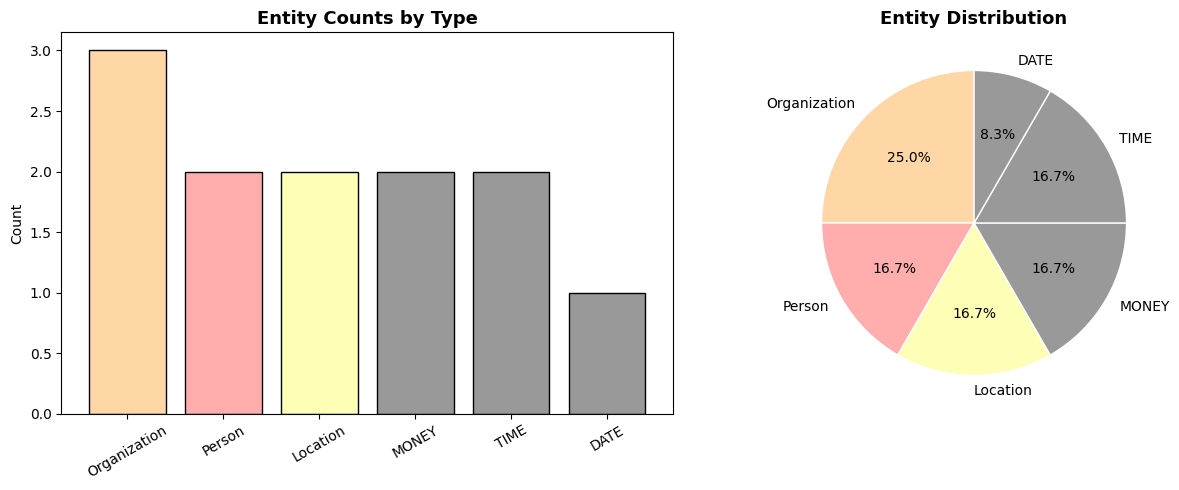

✅ Exported 12 entities to 'demo_extracted_entities.csv'

--- Conclusion ---
A total of **12** named entities were extracted from the input text.
Average model confidence across all entities: **95.44%**.
Breakdown by category:
  - Organization: 3
  - Person: 2
  - Location: 2
  - MONEY: 2
  - TIME: 2
  - DATE: 1
The highest-confidence entity detected was **'Tim Cook'** (Person, 99.97%).


In [ ]:
sample_text = (
    "Tim Cook, the CEO of Apple, announced on 15th March 2024 that the company "
    "will invest $1.2 billion in its new campus in London. The announcement was "
    "made at 10:30 AM during a press conference. Sundar Pichai of Google congratulated "
    "the move, while Microsoft's headquarters in Redmond remained silent on the matter."
)

try:
    demo_entities = extract_all_entities(sample_text)
    demo_df = entities_to_dataframe(demo_entities)

    print(f"Total entities extracted: {len(demo_df)}\n")
    display(demo_df)

    from IPython.display import HTML
    display(HTML(highlight_entities_html(sample_text, demo_entities)))

    plot_entity_charts(demo_df)

    csv_path = export_to_csv(demo_df, "demo_extracted_entities.csv")

    print("\n--- Conclusion ---")
    print(generate_conclusion(demo_df))

except Exception as e:
    print(f"❌ Demo failed: {e}")


## 1️⃣2️⃣ Interactive Gradio Application

Provides a text box, file upload, extract button, highlighted output, entity table, and charts —
all runnable directly inside Colab.


In [ ]:
import gradio as gr
import tempfile


def process_input(text_input: str, uploaded_file):
    """Main handler wired to the Gradio interface."""
    try:
        # Prefer uploaded file content if provided, otherwise use the text box
        if uploaded_file is not None:
            file_path = uploaded_file.name if hasattr(uploaded_file, "name") else uploaded_file
            source_text = load_document_text(file_path)
        else:
            source_text = text_input or ""

        if not source_text.strip():
            raise ValueError("Please enter text or upload a .txt/.pdf file before extracting.")

        entities = extract_all_entities(source_text)
        df = entities_to_dataframe(entities)
        highlighted_html = highlight_entities_html(source_text, entities)

        fig = None
        if not df.empty:
            fig = plot_entity_charts(df)
            plt.close(fig)  # prevent duplicate inline rendering outside Gradio

        conclusion = generate_conclusion(df)
        total_msg = f"### Total entities extracted: {len(df)}"

        # Write CSV for download
        csv_path = os.path.join(tempfile.gettempdir(), "extracted_entities.csv")
        df.to_csv(csv_path, index=False)

        return highlighted_html, df, fig, f"{total_msg}\n\n{conclusion}", csv_path

    except Exception as e:
        error_html = f"<div style='color:red; font-family:sans-serif;'>❌ Error: {e}</div>"
        return error_html, pd.DataFrame(), None, f"❌ Error: {e}", None


with gr.Blocks(title="Advanced NER Extractor") as demo:
    gr.Markdown("# 🔎 Advanced Named Entity Recognition\nExtract Person, Organization, Location, Date, Money & Time entities.")

    with gr.Row():
        with gr.Column(scale=1):
            text_box = gr.Textbox(
                label="Enter Text",
                placeholder="Paste your article, news, or paragraph here...",
                lines=10,
            )
            file_upload = gr.File(
                label="Or Upload a .txt / .pdf File",
                file_types=[".txt", ".pdf"],
            )
            extract_btn = gr.Button("🚀 Extract Entities", variant="primary")

        with gr.Column(scale=1):
            summary_box = gr.Markdown(label="Summary")
            csv_download = gr.File(label="Download CSV")

    highlighted_output = gr.HTML(label="Highlighted Text")
    dataframe_output = gr.Dataframe(label="Extracted Entities", interactive=False)
    chart_output = gr.Plot(label="Entity Distribution Charts")

    extract_btn.click(
        fn=process_input,
        inputs=[text_box, file_upload],
        outputs=[highlighted_output, dataframe_output, chart_output, summary_box, csv_download],
    )

# Launch inside Colab (share=True gives a public link; set to False for local-only)
demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://caf6ef454f61f8ad47.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## ✅ Conclusion

This notebook implemented a complete, production-quality NER pipeline:

- **Model**: `Jean-Baptiste/roberta-large-ner-english` (swap `ACTIVE_MODEL_KEY` to `bert-base-NER` to compare) for Person, Organization, and Location.
- **Rule-based extractors** (regex) fill in Date, Money, and Time — categories not natively output by CoNLL-trained Transformer NER models.
- Sub-word tokens are merged automatically via `aggregation_strategy="simple"`, and duplicate entities are removed while keeping the highest-confidence occurrence.
- Results are presented as a sorted Pandas DataFrame, an inline color-highlighted HTML view, a bar chart, and a pie chart.
- A CSV export is generated and can be downloaded directly, and the same pipeline powers a fully interactive Gradio app with text/file input.

### Possible Extensions
- Fine-tune a single Transformer model on a dataset labeled with all 6 target categories to remove the need for regex fallback.
- Add multi-language support with a multilingual NER checkpoint (e.g. `Davlan/xlm-roberta-base-ner-hrl`).
- Batch-process multiple documents and aggregate entity statistics across a corpus.
